# HyDE (Hypothetical Document Embedding) 실험

HyDE(Hypothetical Document Embeddings)는 **사용자 질문에 대해 LLM(대형 언어 모델)로 가상의 문서를 먼저 생성하고, 이 문서를 임베딩하여 검색하는 방식**이다.  
기존에는 질문 자체를 임베딩해 유사한 문서를 찾았지만, HyDE는 질문의 맥락과 의도를 더 잘 반영할 수 있는 가상 문서를 생성해 임베딩하고, 이를 벡터 DB에서 비교함으로써 **더 정확한 검색 결과**를 얻을 수 있다.

**핵심 요약**
- 질문 → LLM이 가상 문서 생성 → 임베딩 → 벡터 DB에서 유사도 검색
- 기존 방식보다 **질문의 의미와 맥락을 더 잘 반영**하여 검색 정확도 향상
- RAG 등 다양한 검색·생성 AI 시스템에서 활용 가능
- 단점: LLM 사용으로 **속도가 느려질 수 있음**

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [3]:
import pandas as pd

document_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')

In [4]:
# BM25 키워드 검색 모델
# - 문서를 토큰화해서 BM25 모델 생성
# - 검색어도 동일하게 토큰화하여 BM25 검색시 활용
from rank_bm25 import BM25Okapi  # BM 25 기본검색모델
from kiwipiepy import Kiwi

kiwi = Kiwi()

# Kiwi로 문장을 형태소 단위로 토큰화하는 함수
def kiwi_tokenize(doc):
    return [token.form for token in kiwi.tokenize(doc)]

# 문서 내용 토큰화
tokenized_docs = [kiwi_tokenize(doc) for doc in document_df['content']]
bm25 = BM25Okapi(tokenized_docs)  # BM25 모델 생성 (토큰화된 문서)

# 질의문을 토큰화해서 BM25로 상위 문서 검색하는 함수
def bm25_search(query, top_k=5):  
    query_tokens = kiwi_tokenize(query)  # 검색어 토큰화
    scores = bm25.get_scores(query_tokens)  # 각 문서의 BM25 점수 계산

    # 점수 기준 내림차순 정렬한 인덱스
    ranked_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    # 상위 top_k개의 doc_id 리스트
    retrieved_docs = [document_df['doc_id'].iloc[i] for i in ranked_idx[:top_k]]
    return retrieved_docs

bm25_search('제주도 관광 명소')  # 해당 단어와 자주 겹치는 것을 검색해서 가져온다.

['D1', 'D2', 'D3', 'D4', 'D5']

In [5]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')  # 1536차원 임베딩 모델

# 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir',  # 연결할 index명
    embedding = embeddings  # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야 함)
)

### Hyde 가상문서 (가설 답변) 생성 체인 구성

In [6]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = init_chat_model('gpt-5.6-luna', temperature=0.3)
prompt = PromptTemplate.from_template('''
질문 : {query}

위 질문에 대해서 실제 문서가 아니어도 좋으니, 답변을 생성해주세요.
''')

output_parser = StrOutputParser()

hyde_chain = prompt | llm | output_parser

print(hyde_chain.invoke('제주도 관광 명소'))

제주도는 아름다운 자연경관과 독특한 문화가 어우러진 관광 명소가 많은 곳입니다. 대표적인 관광지는 다음과 같습니다.

### 제주 자연 명소
- **한라산 국립공원**: 제주도의 중심에 있는 산으로, 성판악·관음사 코스를 통해 등반할 수 있습니다.
- **성산일출봉**: 유네스코 세계자연유산으로 지정된 대표 명소이며, 정상에서 아름다운 일출을 감상할 수 있습니다.
- **만장굴**: 세계적으로 유명한 용암동굴로, 제주 화산 지형을 가까이에서 볼 수 있습니다.
- **주상절리대**: 바닷가에 형성된 육각형 돌기둥 모양의 절벽이 인상적입니다.
- **협재해수욕장**: 에메랄드빛 바다와 하얀 모래사장으로 유명한 해변입니다.
- **우도**: 제주 본섬에서 배를 타고 이동할 수 있는 섬으로, 검멀레해변과 우도봉 등이 유명합니다.
- **비자림**: 수백 년 된 비자나무가 울창한 숲을 이루고 있어 산책하기 좋습니다.

### 제주 문화·역사 명소
- **제주 민속촌**: 제주 전통 가옥과 생활문화를 체험할 수 있는 곳입니다.
- **제주목 관아**: 조선시대 제주 행정 중심지였던 역사적인 장소입니다.
- **돌문화공원**: 제주 특유의 돌 문화와 설화를 감상할 수 있습니다.
- **성읍민속마을**: 제주 전통 초가와 옛 생활 모습을 보존하고 있는 마을입니다.

### 가족·체험 관광지
- **아쿠아플라넷 제주**: 다양한 해양 생물을 볼 수 있는 대형 아쿠아리움입니다.
- **오설록 티 뮤지엄**: 녹차밭과 차 문화를 즐길 수 있는 인기 명소입니다.
- **카멜리아힐**: 계절별 꽃과 아름다운 정원을 감상할 수 있습니다.
- **제주신화월드**: 쇼핑, 식사, 놀이시설을 함께 즐길 수 있는 복합 리조트입니다.
- **동문시장**: 제주 특산물과 먹거리를 경험할 수 있는 전통시장입니다.

### 추천 여행 코스
- **동부 코스**: 성산일출봉 → 섭지코지 → 우도 → 만장굴  
- **서부 코스**: 협재해수욕장 → 한림공원 → 오설록 티 뮤지엄 → 산방산  
- **

### hyde 가상답변을 쿼리별로 생성/저장

In [7]:
import time
from tqdm.auto import tqdm

hyde_pseudo = {}  # qid별 가상답변 저장 dict

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = hyde_chain.invoke(query_text)  # 가상답변 생성
    hyde_pseudo[qid] = pseudo_answer  # {qid: pseudo_answer, ...}
    time.sleep(0.5)  # AIP 과호출 방지용 딜레이

hyde_pseudo

0it [00:00, ?it/s]

{'Q1': '제주 올레길은 코스마다 풍경과 난이도가 달라서 여행 목적에 맞춰 고르는 것이 좋습니다. 처음 걷는다면 **6코스·7코스·10코스**를 추천합니다.\n\n## 추천 코스\n\n### 1. 7코스: 외돌개~월평\n- **거리:** 약 17~18km\n- **소요 시간:** 5~6시간\n- **난이도:** 중\n- **특징:** 제주 올레길의 대표 코스\n- **볼거리:** 외돌개, 범섬 전망, 월평 해안, 서귀포 해안 풍경\n- **추천 이유:** 바다·절벽·숲길이 고르게 이어져 제주다운 풍경을 한 번에 볼 수 있습니다.\n- **주의:** 해안 바위길과 오르내림이 있어 편한 운동화를 신는 것이 좋습니다.\n\n### 2. 6코스: 쇠소깍~제주올레 여행자센터\n- **거리:** 약 11km\n- **소요 시간:** 3~4시간\n- **난이도:** 쉬움~보통\n- **특징:** 비교적 짧고 접근성이 좋은 코스\n- **볼거리:** 쇠소깍, 서귀포 해안, 정방폭포 인근, 이중섭거리 주변\n- **추천 이유:** 반나절 일정으로 걷기 좋고, 카페나 식당을 들르기도 편합니다.\n- **추천 대상:** 올레길이 처음이거나 가볍게 걷고 싶은 여행객\n\n### 3. 10코스: 화순금모래해변~하모체육공원\n- **거리:** 약 15~16km\n- **소요 시간:** 4~5시간\n- **난이도:** 보통\n- **특징:** 서남부 해안 풍경이 아름다운 코스\n- **볼거리:** 화순금모래해변, 산방산, 송악산, 하모해변\n- **추천 이유:** 산방산과 송악산을 함께 볼 수 있고, 바다 풍경이 시원하게 펼쳐집니다.\n- **주의:** 바람이 강한 날이 많아 방풍 재킷을 준비하는 것이 좋습니다.\n\n### 4. 1코스: 시흥리~광치기해변\n- **거리:** 약 15km\n- **소요 시간:** 4~5시간\n- **난이도:** 보통\n- **특징:** 제주 동부의 들판과 해안 풍경\n- **볼거리:** 말미오름, 알오름, 성산일출봉, 광치기해변\n- **추천 이유:

In [8]:
import pandas as pd

pd.set_option('display.max_colwidth', None)  # 긴 텍스트도 생략 없이 표시

hyde_df = pd.DataFrame({
    'query_id': list(hyde_pseudo.keys()),  # qid 리스트
    'query_text': queries_df['query_text'],  # 원본 질문 Series
    'pseudo_answer': list(hyde_pseudo.values())  # 가상 질문 리스트
})

hyde_df.head()

,query_id,query_text,pseudo_answer
0,Q1,제주도 올레길 트레킹 코스 추천,"제주 올레길은 코스마다 풍경과 난이도가 달라서 여행 목적에 맞춰 고르는 것이 좋습니다. 처음 걷는다면 **6코스·7코스·10코스**를 추천합니다.\n\n## 추천 코스\n\n### 1. 7코스: 외돌개~월평\n- **거리:** 약 17~18km\n- **소요 시간:** 5~6시간\n- **난이도:** 중\n- **특징:** 제주 올레길의 대표 코스\n- **볼거리:** 외돌개, 범섬 전망, 월평 해안, 서귀포 해안 풍경\n- **추천 이유:** 바다·절벽·숲길이 고르게 이어져 제주다운 풍경을 한 번에 볼 수 있습니다.\n- **주의:** 해안 바위길과 오르내림이 있어 편한 운동화를 신는 것이 좋습니다.\n\n### 2. 6코스: 쇠소깍~제주올레 여행자센터\n- **거리:** 약 11km\n- **소요 시간:** 3~4시간\n- **난이도:** 쉬움~보통\n- **특징:** 비교적 짧고 접근성이 좋은 코스\n- **볼거리:** 쇠소깍, 서귀포 해안, 정방폭포 인근, 이중섭거리 주변\n- **추천 이유:** 반나절 일정으로 걷기 좋고, 카페나 식당을 들르기도 편합니다.\n- **추천 대상:** 올레길이 처음이거나 가볍게 걷고 싶은 여행객\n\n### 3. 10코스: 화순금모래해변~하모체육공원\n- **거리:** 약 15~16km\n- **소요 시간:** 4~5시간\n- **난이도:** 보통\n- **특징:** 서남부 해안 풍경이 아름다운 코스\n- **볼거리:** 화순금모래해변, 산방산, 송악산, 하모해변\n- **추천 이유:** 산방산과 송악산을 함께 볼 수 있고, 바다 풍경이 시원하게 펼쳐집니다.\n- **주의:** 바람이 강한 날이 많아 방풍 재킷을 준비하는 것이 좋습니다.\n\n### 4. 1코스: 시흥리~광치기해변\n- **거리:** 약 15km\n- **소요 시간:** 4~5시간\n- **난이도:** 보통\n- **특징:** 제주 동부의 들판과 해안 풍경\n- **볼거리:** 말미오름, 알오름, 성산일출봉, 광치기해변\n- **추천 이유:** 오름에 올라 바라보는 성산일출봉 풍경이 인상적입니다.\n- **추천 대상:** 오름과 해안 풍경을 함께 즐기고 싶은 분\n\n### 5. 18코스: 제주 원도심~조천 만세동산\n- **거리:** 약 19~20km\n- **소요 시간:** 5~6시간\n- **난이도:** 보통\n- **특징:** 제주 시내에서 출발하는 도시·해안 복합 코스\n- **볼거리:** 산지천, 사라봉, 별도봉, 삼양해변, 조천 해안\n- **추천 이유:** 공항이나 제주시 숙소에서 접근하기 편하고, 자연과 제주 생활 풍경을 함께 볼 수 있습니다.\n\n## 여행 스타일별 추천\n\n- **첫 올레길:** 6코스\n- **제주다운 대표 풍경:** 7코스\n- **산방산·송악산 풍경:** 10코스\n- **성산일출봉을 보고 싶을 때:** 1코스\n- **제주시에서 출발하고 싶을 때:** 18코스\n- **짧게 걷고 싶을 때:** 6코스 일부 구간 또는 7코스 일부 구간\n\n## 걷기 전 알아두면 좋은 점\n\n1. 올레길은 포장도로뿐 아니라 돌길, 흙길, 해안 바위길도 포함되어 있습니다. \n **트레킹화나 미끄럼 방지 운동화**를 추천합니다.\n\n2. 코스 중간에 식당이나 편의점이 없는 구간도 있으므로 \n **물과 간단한 간식**을 준비하는 것이 좋습니다.\n\n3. 제주 날씨는 갑자기 바뀔 수 있으므로 \n **모자, 자외선 차단제, 얇은 겉옷, 우비**를 챙기면 유용합니다.\n\n4. 출발 전 제주올레 공식 홈페이지나 안내센터에서 \n **통제 구간과 대중교통 정보를 확인**하는 것이 안전합니다.\n\n개인적으로 첫 방문이라면 **6코스**, 제주 풍경을 제대로 느끼고 싶다면 **7코스**, 날씨가 좋고 서쪽 여행을 계획 중이라면 **10코스**를 가장 추천합니다."
1,Q2,전주 비빔밥 vs 진주 비빔밥 재료 및 맛 차이,"## 전주 비빔밥 vs 진주 비빔밥\n\n두 음식 모두 여러 나물과 밥을 섞어 먹는 전통 비빔밥이지만, **전주는 고추장과 참기름의 진한 풍미**, **진주는 다양한 나물과 육회의 조화, 담백하고 산뜻한 맛**이 상대적으로 두드러집니다. 다만 식당과 가정에 따라 재료와 양념은 달라질 수 있습니다.\n\n| 구분 | 전주 비빔밥 | 진주 비빔밥 |\n|---|---|---|\n| 대표적 특징 | 전주 지역의 풍성한 나물 비빔밥 | ‘꽃밥’, ‘칠보화반’으로도 불리는 화려한 나물 비빔밥 |\n| 밥 | 콩나물이나 소고기 육수로 지은 밥을 쓰는 경우가 많음 | 일반 밥 또는 육수로 지은 밥을 사용 |\n| 주요 나물 | 콩나물, 시금치, 고사리, 도라지, 무나물 등 | 콩나물, 숙주나물, 시금치, 고사리, 도라지, 무나물 등 여러 색의 나물 |\n| 고기 | 소고기 볶음이나 육회가 곁들여지기도 함 | 육회가 중요한 재료로 들어가는 경우가 많음 |\n| 곁들이는 재료 | 달걀, 김, 황포묵, 잣 등 | 육회, 황포묵, 다양한 색의 고명 등 |\n| 양념 | 고추장과 참기름을 비교적 넉넉히 사용 | 고추장과 참기름을 적당히 넣고 재료의 맛을 살리는 편 |\n| 맛 | 고소하고 진하며 달큰하고 매콤함 | 담백하고 깔끔하며 나물과 육회의 신선한 맛이 강조됨 |\n\n### 1. 전주 비빔밥의 재료와 맛\n\n전주 비빔밥은 보통 **콩나물, 고사리, 도라지, 시금치, 무나물, 취나물** 등 여러 가지 나물을 넣습니다. 여기에 소고기, 달걀, 김, 황포묵 등을 더하기도 합니다.\n\n전주 비빔밥의 특징 중 하나는 밥입니다. 콩나물이나 소고기 육수로 밥을 지어 밥 자체에 감칠맛을 내는 방식이 알려져 있습니다. 또한 전주산 고추장과 참기름을 넣어 비비기 때문에 다음과 같은 맛이 납니다.\n\n- 참기름의 고소한 향이 강함\n- 고추장으로 인해 달큰하고 매콤함\n- 여러 나물과 육수 밥이 어우러져 맛이 진하고 풍성함\n- 전체적으로 자극적이면서도 감칠맛이 깊은 편\n\n전주 비빔밥은 재료를 많이 넣고 고추장 양념을 충분히 넣어 **한 그릇의 맛이 풍부하고 진한 스타일**이라고 볼 수 있습니다.\n\n### 2. 진주 비빔밥의 재료와 맛\n\n진주 비빔밥은 여러 나물을 색깔별로 담아 꽃처럼 보이게 하는 것이 특징입니다. 그래서 **꽃밥**, 또는 **칠보화반**이라는 이름으로도 설명됩니다.\n\n주로 콩나물이나 숙주나물, 시금치, 고사리, 도라지, 무나물 등 다양한 나물을 사용하며, **육회나 양념한 소고기**를 함께 올리는 경우가 많습니다. 지역에 따라 황포묵이나 특유의 국물을 곁들이기도 합니다.\n\n맛은 다음과 같은 특징이 있습니다.\n\n- 나물의 향과 식감이 비교적 선명함\n- 육회가 들어가 고소하고 부드러운 맛이 남\n- 고추장을 많이 넣기보다 재료의 맛을 살리는 편\n- 전주 비빔밥보다 상대적으로 담백하고 산뜻함\n- 참기름과 육회의 고소함, 나물의 깔끔한 맛이 조화를 이룸\n\n진주 비빔밥은 고추장 맛이 모든 재료를 덮기보다는, 각각의 나물과 육회의 맛을 느끼며 먹는 **섬세하고 담백한 스타일**에 가깝습니다.\n\n## 핵심적인 차이\n\n쉽게 말하면 다음과 같습니다.\n\n- **전주 비빔밥**: 콩나물밥, 다양한 나물, 고추장, 참기름의 조화가 중심 \n → 진하고 고소하며 달큰하고 매콤한 맛\n\n- **진주 비빔밥**: 색색의 나물과 육회, 재료 자체의 조화가 중심 \n → 담백하고 깔끔하며 육회와 나물의 맛이 잘 드러나는 맛\n\n다만 오늘날에는 전주에서도 육회를 올리고, 진주에서도 고추장을 넉넉히 사용하는 식당이 있어 두 지역의 차이가 항상 뚜렷한 것은 아닙니다. 전통적인 경향으로 비교하면 **전주는 양념과 밥의 풍미가 강하고, 진주는 나물과 육회의 조화가 돋보인다**고 정리할 수 있습니다."
2,Q3,걸스데이 대표 히트곡 목록 알려줘,"걸스데이(Girl’s Day)의 대표적인 히트곡은 다음과 같습니다.\n\n- **〈반짝반짝(Twinkle Twinkle)〉** (2011) \n 대중적으로 이름을 알린 초기 대표곡\n\n- **〈너 한눈 팔지마!〉** (2011) \n

### Hyde(가상답변) 기반 Dense 검색 결과 수집 ([doc_id])

In [ ]:
hyde_results = {}  # qid별 Hyde 검색 결과 {qid: [doc_id, ...], ...}

for idx, row in hyde_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = row['pseudo_answer']
    docs = vector_store.similarity_search(pseudo_answer, k=5)  # 가상답변으로 top_5 벡터 검색
    hyde_results[qid] = [doc.metadata['doc_id'] for doc in docs]  # doc_id만 저장

hyde_results

{'Q1': ['D12', 'D1', 'D8', 'D11', 'D13'],
 'Q2': ['D13', 'D2', 'D16', 'D12', 'D24'],
 'Q3': ['D3', 'D15', 'D17', 'D9', 'D18'],
 'Q4': ['D4', 'D18', 'D15', 'D28', 'D26'],
 'Q5': ['D5', 'D26', 'D7', 'D20', 'D11'],
 'Q6': ['D11', 'D6', 'D25', 'D10', 'D16'],
 'Q7': ['D25', 'D7', 'D29', 'D14', 'D11'],
 'Q8': ['D8', 'D30', 'D11', 'D12', 'D18'],
 'Q9': ['D9', 'D15', 'D29', 'D16', 'D19'],
 'Q10': ['D10', 'D25', 'D15', 'D11', 'D4'],
 'Q11': ['D11', 'D29', 'D28', 'D12', 'D19'],
 'Q12': ['D12', 'D1', 'D11', 'D8', 'D13'],
 'Q13': ['D13', 'D2', 'D11', 'D19', 'D28'],
 'Q14': ['D14', 'D7', 'D26', 'D25', 'D29'],
 'Q15': ['D15', 'D9', 'D19', 'D11', 'D2'],
 'Q16': ['D16', 'D2', 'D9', 'D23', 'D24'],
 'Q17': ['D17', 'D10', 'D25', 'D8', 'D15'],
 'Q18': ['D18', 'D21', 'D4', 'D20', 'D27'],
 'Q19': ['D19', 'D23', 'D24', 'D11', 'D29'],
 'Q20': ['D20', 'D19', 'D7', 'D11', 'D22'],
 'Q21': ['D21', 'D23', 'D18', 'D30', 'D19'],
 'Q22': ['D22', 'D20', 'D23', 'D19', 'D24'],
 'Q23': ['D23', 'D24', 'D22', 'D20', 'D19']

In [10]:
bm25_results = {}            # qid별 BM25 검색 결과 저장 dict
for idx, row in queries_df.iterrows():
    qid = row['query_id']   # 쿼리 ID 추출
    query_text = row['query_text']  # 쿼리 문장
    bm25_results[qid] = bm25_search(query_text, top_k=5)  # {qid: query_text와 가장 가까운 5개의 doc_id}
bm25_results

{'Q1': ['D1', 'D2', 'D3', 'D4', 'D5'],
 'Q2': ['D13', 'D2', 'D1', 'D3', 'D4'],
 'Q3': ['D2', 'D21', 'D14', 'D11', 'D28'],
 'Q4': ['D4', 'D9', 'D1', 'D30', 'D5'],
 'Q5': ['D5', 'D18', 'D19', 'D23', 'D15'],
 'Q6': ['D6', 'D27', 'D17', 'D25', 'D3'],
 'Q7': ['D27', 'D25', 'D7', 'D14', 'D9'],
 'Q8': ['D8', 'D18', 'D30', 'D12', 'D29'],
 'Q9': ['D9', 'D27', 'D1', 'D2', 'D3'],
 'Q10': ['D10', 'D3', 'D17', 'D9', 'D25'],
 'Q11': ['D11', 'D4', 'D14', 'D28', 'D26'],
 'Q12': ['D12', 'D8', 'D9', 'D27', 'D5'],
 'Q13': ['D13', 'D14', 'D26', 'D2', 'D3'],
 'Q14': ['D14', 'D7', 'D25', 'D27', 'D26'],
 'Q15': ['D9', 'D15', 'D26', 'D14', 'D1'],
 'Q16': ['D16', 'D15', 'D9', 'D29', 'D8'],
 'Q17': ['D17', 'D25', 'D6', 'D3', 'D10'],
 'Q18': ['D18', 'D4', 'D28', 'D5', 'D7'],
 'Q19': ['D19', 'D18', 'D14', 'D24', 'D29'],
 'Q20': ['D20', 'D27', 'D10', 'D3', 'D4'],
 'Q21': ['D21', 'D19', 'D25', 'D2', 'D11'],
 'Q22': ['D22', 'D23', 'D19', 'D18', 'D24'],
 'Q23': ['D23', 'D26', 'D24', 'D22', 'D19'],
 'Q24': ['D24', 'D2

In [11]:
# Vector Store 검색 결과를 쿼리별로 수집
dense_results = {}            # qid별 Dense 검색 결과 저장 dict
for idx, row in queries_df.iterrows():
    qid = row['query_id']   # 쿼리 ID 추출
    query_text = row['query_text']  # 쿼리 문장
    # {qid: query_text와 가장 가까운 5개의 doc_id}
    docs = vector_store.similarity_search(query_text, k=5)  # 벡터 유사도 기준 top-5 문서 검색
    dense_results[qid] = [doc.metadata['doc_id'] for doc in docs]  # doc_id만 리스트로 저장
dense_results

{'Q1': ['D12', 'D1', 'D13', 'D8', 'D9'],
 'Q2': ['D13', 'D2', 'D12', 'D24', 'D8'],
 'Q3': ['D3', 'D17', 'D15', 'D18', 'D29'],
 'Q4': ['D4', 'D16', 'D26', 'D15', 'D18'],
 'Q5': ['D5', 'D23', 'D7', 'D14', 'D26'],
 'Q6': ['D6', 'D14', 'D25', 'D13', 'D17'],
 'Q7': ['D25', 'D7', 'D29', 'D14', 'D17'],
 'Q8': ['D8', 'D12', 'D18', 'D30', 'D17'],
 'Q9': ['D9', 'D3', 'D19', 'D15', 'D12'],
 'Q10': ['D10', 'D25', 'D4', 'D15', 'D3'],
 'Q11': ['D11', 'D18', 'D19', 'D12', 'D23'],
 'Q12': ['D12', 'D8', 'D1', 'D13', 'D9'],
 'Q13': ['D13', 'D2', 'D19', 'D24', 'D23'],
 'Q14': ['D14', 'D6', 'D26', 'D25', 'D7'],
 'Q15': ['D15', 'D14', 'D11', 'D9', 'D26'],
 'Q16': ['D16', 'D23', 'D9', 'D19', 'D22'],
 'Q17': ['D17', 'D25', 'D15', 'D10', 'D3'],
 'Q18': ['D18', 'D4', 'D27', 'D14', 'D26'],
 'Q19': ['D19', 'D18', 'D27', 'D24', 'D28'],
 'Q20': ['D20', 'D19', 'D22', 'D18', 'D24'],
 'Q21': ['D21', 'D23', 'D18', 'D24', 'D30'],
 'Q22': ['D22', 'D23', 'D24', 'D19', 'D11'],
 'Q23': ['D23', 'D24', 'D22', 'D20', 'D19'],


In [12]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')  # 1536차원 임베딩 모델

# 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir',  # 연결할 index명
    embedding = embeddings  # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야 함)
)
import numpy as np 

def parse_relevant(relevant_str) -> dict[str, int]:
    """
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1': 3, 'D4': 1, 'D30': 1}
    """
    pairs = relevant_str.split(';')  # ';' 기준으로 분리
    rel_dict = {}  # {doc_id: grade, ...}
    for pair in pairs:
        doc_id, grade = pair.split('=')  # '=' 기준으로 분리
        rel_dict[doc_id] = int(grade)  # {doc_id: grade, ...}  # grade는 int형으로 변환해 값으로써 넣어줌
    return rel_dict

# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])  # top_k 개 적중 개수
    predicted = hits / k  # 정밀도 = 맞춘 갯수 / 전체 갯수

    # Recall@k
    total_relevant = len(relevant_dict)  # 전체 관련 문서 수 
    recall = hits / total_relevant if total_relevant > 0 else 0  # 재현율 = 관련 문서 맞춘 수

    # MRR 예측치 중 첫 관련문서 순위 점수
    rr = 0   # 관련 문서 수 
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)  # 첫 적중 순위 역수
            break  # 첫 번째 적중 rr 반영 후 반복문 탈출

    # AP (MAP를 위한 사전 계산)
    num_correct = 0  # 현재까지의 적중 횟수
    precisions = []  # 적중시의 precisions
    for idx, doc in enumerate(predicted[:k]):  # top-k 범위에서
        if doc in relevant_dict:
            num_correct += 1  # 적중시 1 누적
            precisions.append(num_correct / (idx + 1))  # 현재 시점의 precisions 기록
    ap = np.mean(precisions) if precisions else 0  # precisions 평균치 사용, 없으면 0

    return precisions, recall, rr, ap

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []  # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid = row['query_id']  # 쿼리 ID
        relevant_dict = parse_relevant(row['relevant_doc_ids'])  # 정답 dict 파싱
        predicted = method_results[qid]  # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)  # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return{
        'P@k': np.mean(prec_list),  # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),  # 쿼리 평균 MRR
        'MAP': np.mean(ap_list)  # 쿼리 평균 MAP
    }

In [13]:
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # 1. Precision@k (단일 float 값)
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])
    precision = hits / k

    # 2. Recall@k
    total_relevant = len(relevant_dict)
    recall = hits / total_relevant if total_relevant > 0 else 0

    # 3. MRR
    rr = 0
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)
            break

    # 4. AP (Average Precision)
    num_correct = 0
    prec_at_hits = []
    for idx, doc in enumerate(predicted[:k]):
        if doc in relevant_dict:
            num_correct += 1
            prec_at_hits.append(num_correct / (idx + 1))
    ap = np.mean(prec_at_hits) if prec_at_hits else 0.0

    # 주의: 첫 번째 반환값을 리스트(prec_at_hits)가 아닌 단일 float(precision)으로 반환합니다.
    return precision, recall, rr, ap

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []  # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid = row['query_id']  # 쿼리 ID
        relevant_dict = parse_relevant(row['relevant_doc_ids'])  # 정답 dict 파싱
        predicted = method_results[qid]  # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)  # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return{
        'P@k': np.mean(prec_list),  # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),  # 쿼리 평균 MRR
        'MAP': np.mean(ap_list)  # 쿼리 평균 MAP
    }

In [14]:
# BM25 / Dense 결과로 P@5, R@5, MRR, MAP 계산
bm25_metrics = evaluate_all(bm25_results, queries_df, k=5)
dense_metrics = evaluate_all(dense_results, queries_df, k=5)
hyde_metrics = evaluate_all(hyde_results, queries_df, k=5)

In [ ]:
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],  # 지표 이름
    'BM25': [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']],
    'Dense': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'RRF': [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']]
})
metrics_df

,Metrics,BM25,Dense,RRF
0,P@5,0.233333,0.246667,0.246667
1,R@5,0.838889,0.888889,0.894444
2,MRR,0.900000,0.950000,0.950000
3,MAP,0.874444,0.920556,0.938889


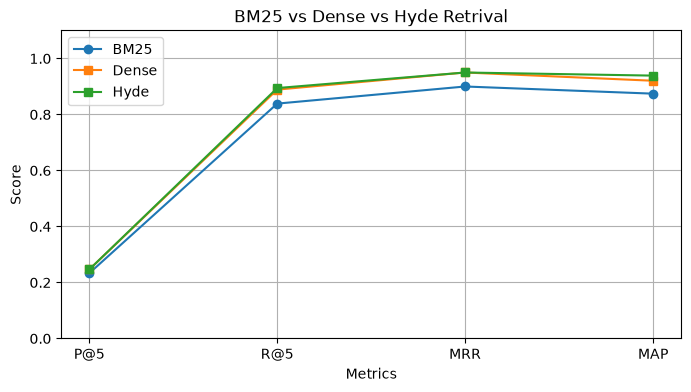

In [16]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
bm25_vals = [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']]
dense_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
hyde_vals = [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']]

x = range(len(metrics))  # 0~3

plt.figure(figsize=(8, 4))
plt.plot(x, bm25_vals, marker='o', label='BM25')
plt.plot(x, dense_vals, marker='s', label='Dense')
plt.plot(x, hyde_vals, marker='s', label='Hyde')
plt.xticks(x, metrics)  # x축 눈금은 0~3 -> 지표명
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('BM25 vs Dense vs Hyde Retrival')
plt.legend()
plt.grid()
plt.show()

##### HyDE의 역할과 효과
- HyDE는 쿼리를 “의미가 풍부한 가상문서”로 확장
- Dense가 이미 강력한 경우:
    - 성능을 보완하거나 유지
    - 항상 큰 폭의 개선을 보장하지는 않음
- 하지만 쿼리가 짧거나 모호한 경우, HyDE의 효과는 더욱 커질 가능성 있음

- Dense Retrieval은 의미 기반 검색의 기본 선택지
- HyDE는 다음 상황에서 특히 유용:
    - 짧고 추상적인 쿼리
    - 질문형 질의
    - Recall 개선이 중요한 경우
- 실서비스에서는: Dense + (HyDE / BM25 / Rerank) 조합이 가장 현실적인 접근

Dense = 벡터DB에서 검색 / 문맥의 의미 유사도 검색  
Hyde = 벡터DB 검색 쿼리를 LLM 요청 수정하는 경우  
BM25 = 문맥상(형태소상) 자주 나오는 단어로 검색  
Rerank = 두가지 기법을 합쳐서 다시 랭킹  